# Linear Regression và dự đoán số nội dung trên Netflix

Mục tiêu:

- Huấn luyện mô hình Linear Regression bằng dữ liệu 2011-2019.
- Kiểm tra mô hình trên dữ liệu năm 2020.
- Đánh giá bằng $MAE$, $RMSE$, và $R^2$.
- Fit lại mô hình trên toàn bộ 2011-2020.
- Ngoại suy số nội dung được thêm trong 12 tháng tiếp theo.

## Import thư viện

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Đọc dữ liệu

In [2]:
ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent

file_path = ROOT / "data" / "normalized" / "fact_monthly_addition.csv"

df = pd.read_csv(file_path)

df["month"] = pd.to_datetime(
    df["date_key"].astype(str),
    format="%Y%m%d",
)

df.head()

,date_key,monthly_additions,month_index,month
0,20110101,0,0,2011-01-01
1,20110201,0,1,2011-02-01
2,20110301,0,2,2011-03-01
3,20110401,0,3,2011-04-01
4,20110501,1,4,2011-05-01


## Kiểm tra dữ liệu

In [3]:
print("Số tháng: ", len(df))
print("Từ tháng: ", df["month"].min())
print("Đến tháng: ", df["month"].max())
print("Tổng số nội dung: ", df["monthly_additions"].sum())

assert len(df) == 120
assert df["date_key"].is_unique
assert df["month_index"].tolist() == list(range(120))
assert df["monthly_additions"].sum() == 7294

print("Dữ liệu hợp lệ.")

Số tháng:  120
Từ tháng:  2011-01-01 00:00:00
Đến tháng:  2020-12-01 00:00:00
Tổng số nội dung:  7294
Dữ liệu hợp lệ.


## Vẽ chuỗi dữ liệu gốc

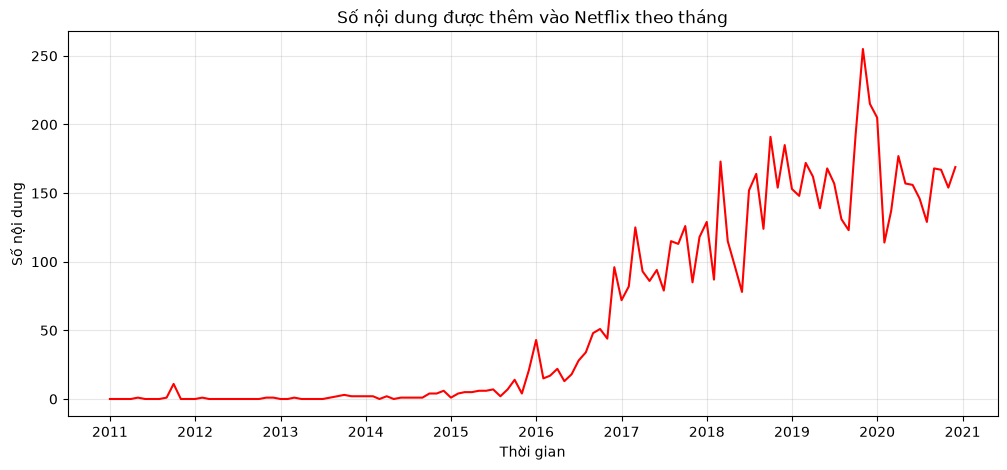

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["month"],
    df["monthly_additions"],
    color="red"
)

plt.title("Số nội dung được thêm vào Netflix theo tháng")
plt.xlabel("Thời gian")
plt.ylabel("Số nội dung")
plt.grid(alpha=0.3)
plt.show()

## Chia tập train và test

In [5]:
train = df[df["month"].dt.year <= 2019].copy()
test = df[df["month"].dt.year == 2020].copy()

X_train = train[["month_index"]]
y_train = train["monthly_additions"]

X_test = test[["month_index"]]
y_test = test["monthly_additions"]

print(f"Train: {len(train)} tháng")
print(f"Test: {len(test)} tháng")

Train: 108 tháng
Test: 12 tháng


## Huấn luyện mô hình

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

train["predicted"] = model.predict(X_train)
test["predicted"] = model.predict(X_test)

print("Hệ số", model.coef_[0])
print("Hệ số chặn: ", model.intercept_)

Hệ số 1.8232730286661514
Hệ số chặn:  -47.40621814475021


Phương trình hồi quy tuyến tính có dạng: $y = ax + b $

Tương đương với dữ liệu của project: monthly_additions = coefficient * month_index + intercept

Suy ra phương trình của mô hình có dạng: $y = 1.8233x - 47.4062$

## Tính $MAE$, $RMSE$ và $R^2$

In [7]:
mae = mean_absolute_error(
    y_test,
    test["predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test["predicted"]
    )
)

r2 = r2_score(
    y_test,
    test["predicted"]
)

metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2]
})

metrics

,metric,value
0,MAE,16.736121
1,RMSE,23.711895
2,R2,-0.082834


## Actual và Predicted năm 2020

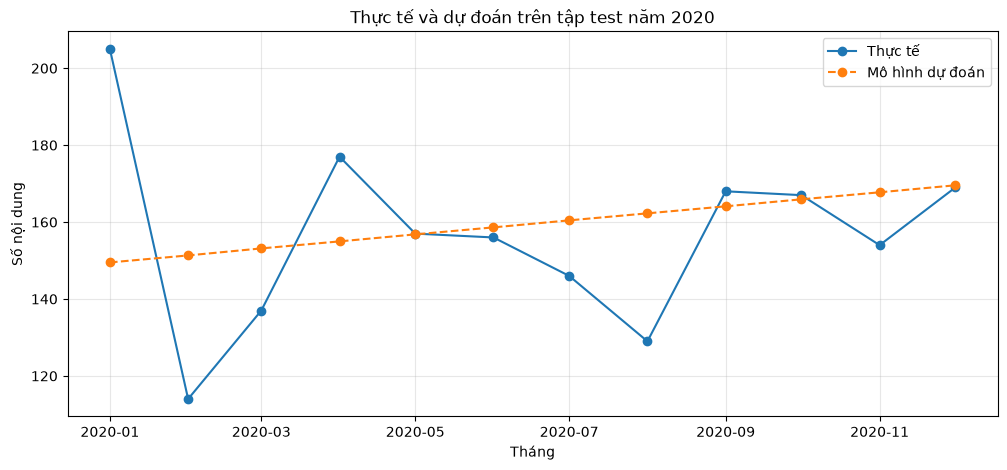

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["month"],
    test["monthly_additions"],
    marker="o",
    label="Thực tế"
)

plt.plot(
    test["month"],
    test["predicted"],
    marker="o",
    linestyle="--",
    label="Mô hình dự đoán"
)

plt.title("Thực tế và dự đoán trên tập test năm 2020")
plt.xlabel("Tháng")
plt.ylabel("Số nội dung")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Fit lại toàn bộ dữ liệu

In [9]:
final_model = LinearRegression()

final_model.fit(
    df[["month_index"]],
    df["monthly_additions"]
)

df["fitted"] = final_model.predict(
    df[["month_index"]]
)

print("Hệ số cuối:", final_model.coef_[0])
print("Hệ số chặn cuối:", final_model.intercept_)

Hệ số cuối: 1.8082991874435725
Hệ số chặn cuối: -46.810468319559234


## Forecast 12 tháng

In [10]:
first_future_index = df["month_index"].max() + 1

future = pd.DataFrame({
    "month_index": range(
        first_future_index,
        first_future_index + 12
    )
})

future["month"] = pd.date_range(
    start="2021-01-01",
    periods=12,
    freq="MS"
)

future["forecast"] = final_model.predict(
    future[["month_index"]]
)

future["forecast_rounded"] = (
    future["forecast"]
    .round()
    .astype(int)
)

future

,month_index,month,forecast,forecast_rounded
0,120,2021-01-01,170.185434,170
1,121,2021-02-01,171.993733,172
2,122,2021-03-01,173.802033,174
3,123,2021-04-01,175.610332,176
4,124,2021-05-01,177.418631,177
5,125,2021-06-01,179.226930,179
6,126,2021-07-01,181.035229,181
7,127,2021-08-01,182.843528,183
8,128,2021-09-01,184.651828,185
9,129,2021-10-01,186.460127,186


## Biểu đồ tổng hợp

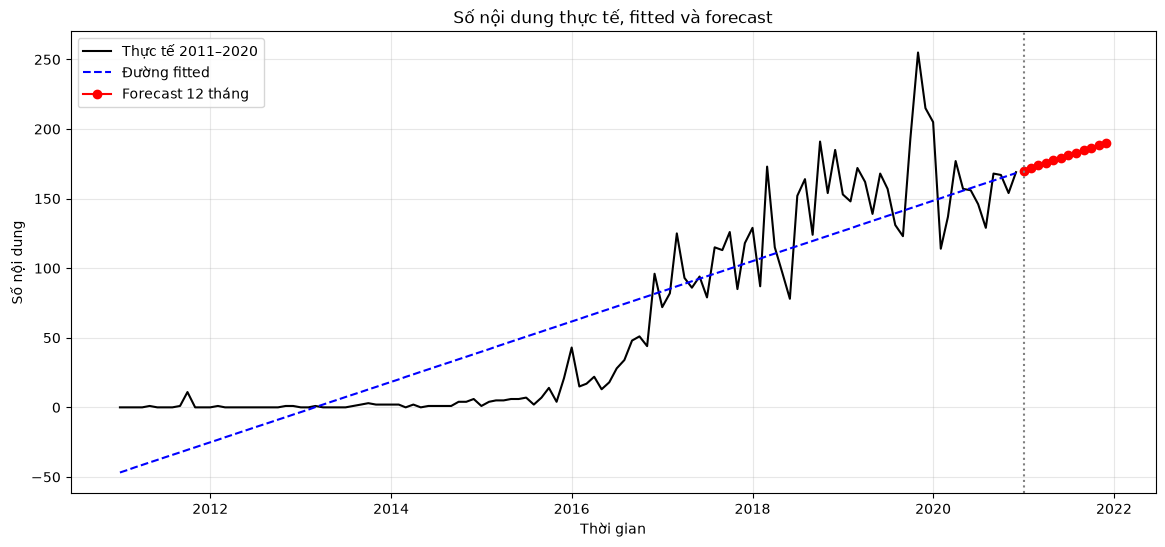

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["month"],
    df["monthly_additions"],
    label="Thực tế 2011–2020",
    color="black"
)

plt.plot(
    df["month"],
    df["fitted"],
    label="Đường fitted",
    color="blue",
    linestyle="--"
)

plt.plot(
    future["month"],
    future["forecast"],
    label="Forecast 12 tháng",
    color="red",
    marker="o"
)

plt.axvline(
    pd.Timestamp("2021-01-01"),
    color="gray",
    linestyle=":"
)

plt.title("Số nội dung thực tế, fitted và forecast")
plt.xlabel("Thời gian")
plt.ylabel("Số nội dung")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
output_dir = ROOT / "data" / "model_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

metrics.to_csv(
    output_dir / "model_metrics.csv",
    index=False
)

future[
    ["month", "month_index", "forecast", "forecast_rounded"]
].to_csv(
    output_dir / "forecast_12_months.csv",
    index=False
)

## Nhận xét

- MAE khoảng 16,74 nghĩa là dự đoán lệch trung bình khoảng 17 nội dung mỗi tháng.
- RMSE khoảng 23,71, lớn hơn MAE, cho thấy một số tháng có sai số tương đối lớn.
- R² âm cho thấy mô hình tuyến tính đơn giản chưa mô tả tốt biến động của năm 2020.
- Mô hình chỉ sử dụng xu hướng thời gian và không xử lý mùa vụ hoặc các biến động bất thường.
- Forecast 12 tháng là ngoại suy từ snapshot dữ liệu đến hết năm 2020, không phải số liệu thực tế của năm 2021.
- Đường fitted cho giá trị âm ở một số tháng đầu kỳ, cho thấy Linear Regression chỉ phù hợp làm mô hình baseline cho chuỗi này.
- Khi fit trên toàn bộ giai đoạn, hệ số khoảng 1,81 cho thấy xu hướng dài hạn tăng trung bình khoảng 1,81 title mỗi tháng. Tuy nhiên, R² âm trên tập test cho thấy mô hình không nắm bắt tốt dao động từng tháng.
- Vì vậy, mô hình đáp ứng mục tiêu minh họa xu hướng của đồ án nhưng không nên được xem là dự báo vận hành chính thức của Netflix.